In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Análisis Exploratorio de Datos - SpyGame

## Objetivo
Analizar los datos de usuarios y sesiones del juego SpyGame, expandiendo las listas de hints y guesses para crear un dataset donde cada fila representa un hint individual y su guess correspondiente.

## 1. Carga de Datos

In [2]:
# Cargar datos de usuarios

users_data = []
with open('data/20260122_users.json', 'r', encoding='utf-8') as f:
    for line in f:
        users_data.append(json.loads(line))

df_users = pd.DataFrame(users_data)
print(f"Usuarios cargados: {len(df_users)}")
df_users.head()

Usuarios cargados: 21


,_id,username,password,created_at,knowledge_profile
0,{'$oid': '6939256cfdc2050a76d917ab'},alonso02_rupa,pbkdf2:sha256:600000$pxJ8uj5yhkiMMLMt$c7172e6d...,2025-12-10T07:46:52.028633,NaN
1,{'$oid': '693ff061fdc2050a76d91834'},TrialUser,pbkdf2:sha256:600000$SOQ3KCR43TOBpTfQ$92e7291c...,2025-12-15T11:26:25.480719,"{'cultura_general': 1, 'geografia': 1, 'actual..."
2,{'$oid': '694275fbfdc2050a76d918a4'},juanmooreno,pbkdf2:sha256:600000$JGg9LcjMVC0joqqo$da9b6bec...,2025-12-17T09:20:59.715241,"{'cultura_general': 4, 'geografia': 4, 'actual..."
3,{'$oid': '694288d2fdc2050a76d918d3'},Laura,pbkdf2:sha256:600000$EM1kxTKWgjgbyEZZ$169e1370...,2025-12-17T10:41:22.429533,"{'cultura_general': 2, 'geografia': 1, 'actual..."
4,{'$oid': '6942aefbeb6a8ac082995c19'},danielpenap,pbkdf2:sha256:600000$E7ybAm8RI73SZhlC$0ad408cd...,2025-12-17T13:24:11.904695,"{'cultura_general': 4, 'geografia': 2, 'actual..."


In [3]:
# Cargar datos de sesiones
sessions_data = []
with open('data/20260122_sessions.json', 'r', encoding='utf-8') as f:
    for line in f:
        sessions_data.append(json.loads(line))

df_sessions = pd.DataFrame(sessions_data)
print(f"Sesiones cargadas: {len(df_sessions)}")
df_sessions.head()

Sesiones cargadas: 789


,_id,session_id,person,pista,guesses,acierto,timestamp,last_updated,username,pistas_order
0,{'$oid': '6939256efdc2050a76d917ae'},c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,[Padeció saturnismo debido a la ingesta de agu...,"[, , , ]",False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403,alonso02_rupa,NaN
1,{'$oid': '693925d0fdc2050a76d917bf'},b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,[Fue influenciado por la correspondencia con L...,"[, , ]",False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897,alonso02_rupa,NaN
2,{'$oid': '693927d0fdc2050a76d917cd'},587ba249-91b7-4487-8dc8-dfd568efe190,Charles Chaplin,[Fue cofundador de la compañía de distribución...,[],False,2025-12-10T07:57:04.046292,2025-12-10T07:57:11.312833,alonso02_rupa,NaN
3,{'$oid': '69392907fdc2050a76d917d5'},9c8e5d97-6687-48ac-bd6e-243825d7aad0,Winston Churchill,[Fue un prolífico pintor y ganador del Premio ...,"[, , , ]",False,2025-12-10T08:02:15.763960,2025-12-10T08:02:30.081922,NaN,NaN
4,{'$oid': '69395279fdc2050a76d917e5'},c7738018-5252-4488-993f-213ed16a142a,Galileo Galilei,[Descubrió la ley de la isocronismo de los pén...,"[Prueba123, Nose, Galileo]",True,2025-12-10T10:59:05.303307,2025-12-10T10:59:23.786848,alonso02_rupa,NaN


## 2. Exploración Inicial - Usuarios

In [4]:
# Información general de usuarios
print("=== Información del Dataset de Usuarios ===")
print(f"\nShape: {df_users.shape}")
print(f"\nColumnas: {df_users.columns.tolist()}")
print(f"\nTipos de datos:")
print(df_users.dtypes)
print(f"\nValores nulos:")
print(df_users.isnull().sum())

=== Información del Dataset de Usuarios ===

Shape: (21, 5)

Columnas: ['_id', 'username', 'password', 'created_at', 'knowledge_profile']

Tipos de datos:
_id                  object
username             object
password             object
created_at           object
knowledge_profile    object
dtype: object

Valores nulos:
_id                  0
username             0
password             0
created_at           0
knowledge_profile    6
dtype: int64


In [5]:
# Usuarios con perfil de conocimiento completado
users_with_profile = df_users['knowledge_profile'].notna().sum()
print(f"Usuarios con perfil de conocimiento: {users_with_profile} / {len(df_users)}")
print(f"Porcentaje: {users_with_profile/len(df_users)*100:.2f}%")

Usuarios con perfil de conocimiento: 15 / 21
Porcentaje: 71.43%


## 3. Exploración Inicial - Sesiones

In [6]:
# Información general de sesiones
print("=== Información del Dataset de Sesiones ===")
print(f"\nShape: {df_sessions.shape}")
print(f"\nColumnas: {df_sessions.columns.tolist()}")
print(f"\nTipos de datos:")
print(df_sessions.dtypes)
print(f"\nValores nulos:")
print(df_sessions.isnull().sum())

=== Información del Dataset de Sesiones ===

Shape: (789, 10)

Columnas: ['_id', 'session_id', 'person', 'pista', 'guesses', 'acierto', 'timestamp', 'last_updated', 'username', 'pistas_order']

Tipos de datos:
_id             object
session_id      object
person          object
pista           object
guesses         object
acierto           bool
timestamp       object
last_updated    object
username        object
pistas_order    object
dtype: object

Valores nulos:
_id               0
session_id        0
person            0
pista             0
guesses           0
acierto           0
timestamp         0
last_updated      0
username        476
pistas_order    104
dtype: int64


In [7]:
# Análisis básico de sesiones
print("=== Análisis Básico de Sesiones ===")
print(f"\nSesiones con acierto: {df_sessions['acierto'].sum()}")
print(f"Sesiones sin acierto: {(~df_sessions['acierto']).sum()}")
print(f"Tasa de acierto: {df_sessions['acierto'].mean()*100:.2f}%")
print(f"\nPersonajes únicos: {df_sessions['person'].nunique()}")
print(f"\nTop 10 personajes más jugados:")
print(df_sessions['person'].value_counts().head(10))

=== Análisis Básico de Sesiones ===

Sesiones con acierto: 552
Sesiones sin acierto: 237
Tasa de acierto: 69.96%

Personajes únicos: 45

Top 10 personajes más jugados:
person
Winston Churchill    41
Mahatma Gandhi       40
Vladimir Putin       40
Galileo Galilei      38
Isaac Newton         36
Buda Gautama         36
Iosif Stalin         35
Pablo Picasso        35
Dante Alighieri      34
Leonardo da Vinci    34
Name: count, dtype: int64


## 4. Explotación de Listas: Hints y Guesses

Ahora vamos a expandir las listas `pista` (hints) y `guesses` de forma que cada fila represente un hint individual con su guess correspondiente.

In [8]:
# Función para expandir hints y guesses
def expand_hints_guesses(df):
    """
    Expande las listas de hints (pista) y guesses de forma que cada fila
    represente un hint individual con su guess correspondiente.
    """
    expanded_rows = []
    
    for idx, row in df.iterrows():
        session_id = row['session_id']
        person = row['person']
        acierto = row['acierto']
        username = row.get('username', None)
        timestamp = row.get('timestamp', None)
        last_updated = row.get('last_updated', None)
        
        hints = row['pista']
        guesses = row['guesses']
        
        # Asegurarse de que guesses tenga la misma longitud que hints
        # (rellenar con valores vacíos si es necesario)
        num_hints = len(hints)
        num_guesses = len(guesses)
        
        # Extender guesses si es más corto
        if num_guesses < num_hints:
            guesses = guesses + [''] * (num_hints - num_guesses)
        
        # Crear una fila por cada hint
        for hint_num, (hint, guess) in enumerate(zip(hints, guesses), start=1):
            expanded_rows.append({
                'session_id': session_id,
                'person': person,
                'username': username,
                'acierto': acierto,
                'hint_number': hint_num,
                'total_hints': num_hints,
                'hint': hint,
                'guess': guess,
                'guess_not_empty': guess != '',
                'timestamp': timestamp,
                'last_updated': last_updated
            })
    
    return pd.DataFrame(expanded_rows)

# Expandir el dataset
df_expanded = expand_hints_guesses(df_sessions)
print(f"Dataset original: {len(df_sessions)} sesiones")
print(f"Dataset expandido: {len(df_expanded)} filas (hint-guess pairs)")
print(f"\nPrimeras filas del dataset expandido:")
df_expanded.head(10)

Dataset original: 789 sesiones
Dataset expandido: 2293 filas (hint-guess pairs)

Primeras filas del dataset expandido:


,session_id,person,username,acierto,hint_number,total_hints,hint,guess,guess_not_empty,timestamp,last_updated
0,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,1,5,Padeció saturnismo debido a la ingesta de agua...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
1,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,2,5,Su muerte se atribuye a una insuficiencia hepá...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
2,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,3,5,Compuso treinta y dos sonatas para piano y nue...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
3,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,4,5,Su ópera Fidelio es una de sus obras más desta...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
4,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,5,5,Fue el último gran representante del clasicism...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
5,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,1,4,Fue influenciado por la correspondencia con Le...,,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897
6,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,2,4,Estudió Derecho en Londres y regresó a la Indi...,,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897
7,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,3,4,Instauró métodos de lucha social novedosos com...,,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897
8,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,4,4,Participó en la Conferencia de Londres en 1931...,,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897
9,587ba249-91b7-4487-8dc8-dfd568efe190,Charles Chaplin,alonso02_rupa,False,1,2,Fue cofundador de la compañía de distribución ...,,False,2025-12-10T07:57:04.046292,2025-12-10T07:57:11.312833


## 5. Análisis del Dataset Expandido

In [9]:
# Estadísticas del dataset expandido
print("=== Estadísticas del Dataset Expandido ===")
print(f"\nTotal de hint-guess pairs: {len(df_expanded)}")
print(f"Guesses no vacíos: {df_expanded['guess_not_empty'].sum()}")
print(f"Guesses vacíos: {(~df_expanded['guess_not_empty']).sum()}")
print(f"Porcentaje de guesses realizados: {df_expanded['guess_not_empty'].mean()*100:.2f}%")

print("\n=== Distribución por número de hint ===")
print(df_expanded['hint_number'].value_counts().sort_index())

print("\n=== Estadísticas por hint_number ===")
hint_stats = df_expanded.groupby('hint_number').agg({
    'guess_not_empty': ['sum', 'count', 'mean'],
    'session_id': 'nunique'
}).round(3)
hint_stats.columns = ['guesses_realizados', 'total_filas', 'tasa_guess', 'sesiones_unicas']
print(hint_stats)

=== Estadísticas del Dataset Expandido ===

Total de hint-guess pairs: 2293
Guesses no vacíos: 383
Guesses vacíos: 1910
Porcentaje de guesses realizados: 16.70%

=== Distribución por número de hint ===
hint_number
1    789
2    498
3    346
4    239
5    166
6    114
7     83
8     58
Name: count, dtype: int64

=== Estadísticas por hint_number ===
             guesses_realizados  total_filas  tasa_guess  sesiones_unicas
hint_number                                                              
1                            25          789       0.032              789
2                           144          498       0.289              498
3                            69          346       0.199              346
4                            50          239       0.209              239
5                            40          166       0.241              166
6                            23          114       0.202              114
7                            21           83       0.253  

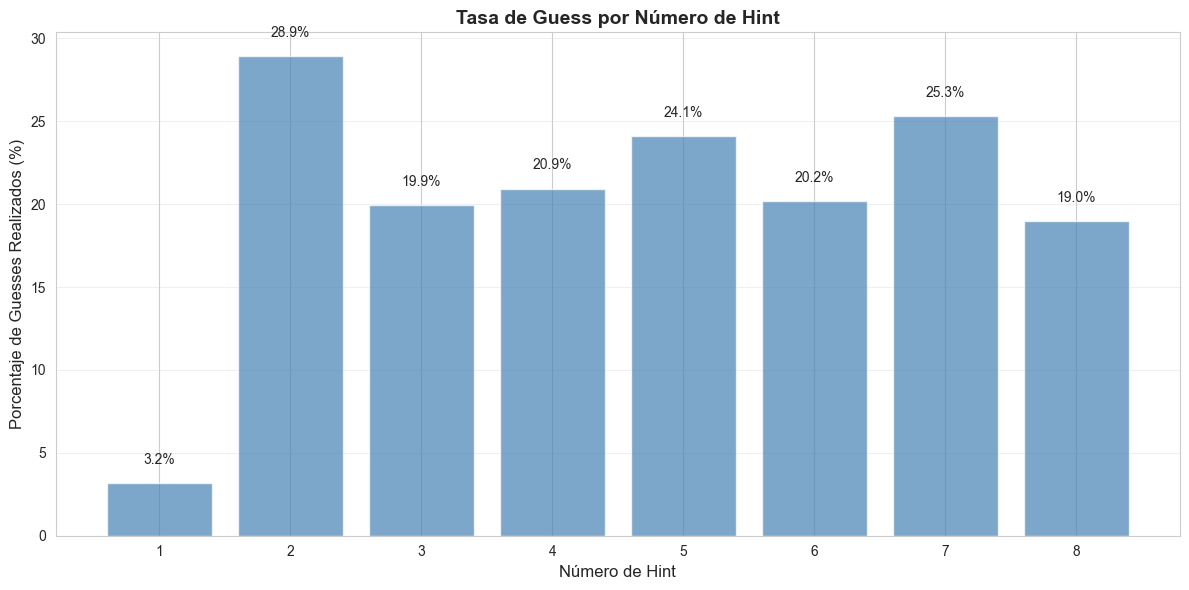

In [10]:
# Visualización: Tasa de guess por número de hint
plt.figure(figsize=(12, 6))
hint_stats_plot = df_expanded.groupby('hint_number')['guess_not_empty'].mean() * 100
plt.bar(hint_stats_plot.index, hint_stats_plot.values, color='steelblue', alpha=0.7)
plt.xlabel('Número de Hint', fontsize=12)
plt.ylabel('Porcentaje de Guesses Realizados (%)', fontsize=12)
plt.title('Tasa de Guess por Número de Hint', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(hint_stats_plot.index)
for i, v in enumerate(hint_stats_plot.values):
    plt.text(hint_stats_plot.index[i], v + 1, f'{v:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 6. Análisis de Usuarios con Perfil de Conocimiento

In [11]:
# Extraer perfiles de conocimiento
profiles = []
for idx, row in df_users.iterrows():
    if pd.notna(row['knowledge_profile']):
        profile = row['knowledge_profile']
        profile['username'] = row['username']
        profiles.append(profile)

df_profiles = pd.DataFrame(profiles)

# Excluir la columna de timestamp
knowledge_cols = [col for col in df_profiles.columns if col not in ['username', 'profile_completed_at']]

print("=== Estadísticas de Perfiles de Conocimiento ===")
print(f"\nUsuarios con perfil: {len(df_profiles)}")
print(f"\nCategorías de conocimiento:")
print(knowledge_cols)
print("\nEstadísticas descriptivas:")
print(df_profiles[knowledge_cols].describe())

# Crear un dataframe completo de knowledge_profile con todos los usuarios
# (con NaN para usuarios sin perfil)
df_users_knowledge = df_users[['username']].copy()
if len(df_profiles) > 0:
    df_users_knowledge = df_users_knowledge.merge(
        df_profiles, 
        on='username', 
        how='left'
    )
    print(f"\nDataframe de usuarios con knowledge_profile creado: {len(df_users_knowledge)} usuarios")
else:
    print("\nNo hay usuarios con knowledge_profile")
    for col in knowledge_cols:
        df_users_knowledge[col] = np.nan

=== Estadísticas de Perfiles de Conocimiento ===

Usuarios con perfil: 15

Categorías de conocimiento:
['cultura_general', 'geografia', 'actualidad_noticias', 'cultura_popular', 'tecnologia_tendencias', 'uso_wikipedia', 'habilidad_busqueda', 'pensamiento_critico']

Estadísticas descriptivas:


       cultura_general  geografia  actualidad_noticias  cultura_popular  \
count        15.000000  15.000000            15.000000        15.000000   
mean          3.200000   3.133333             3.333333         3.466667   
std           1.207122   1.302013             1.234427         1.245946   
min           1.000000   1.000000             1.000000         1.000000   
25%           3.000000   2.500000             3.000000         3.000000   
50%           3.000000   4.000000             4.000000         4.000000   
75%           4.000000   4.000000             4.000000         4.000000   
max           5.000000   5.000000             5.000000         5.000000   

       tecnologia_tendencias  uso_wikipedia  habilidad_busqueda  \
count              15.000000      15.000000           15.000000   
mean                3.800000       3.000000            4.133333   
std                 1.424279       1.511858            1.407463   
min                 1.000000       1.000000            1

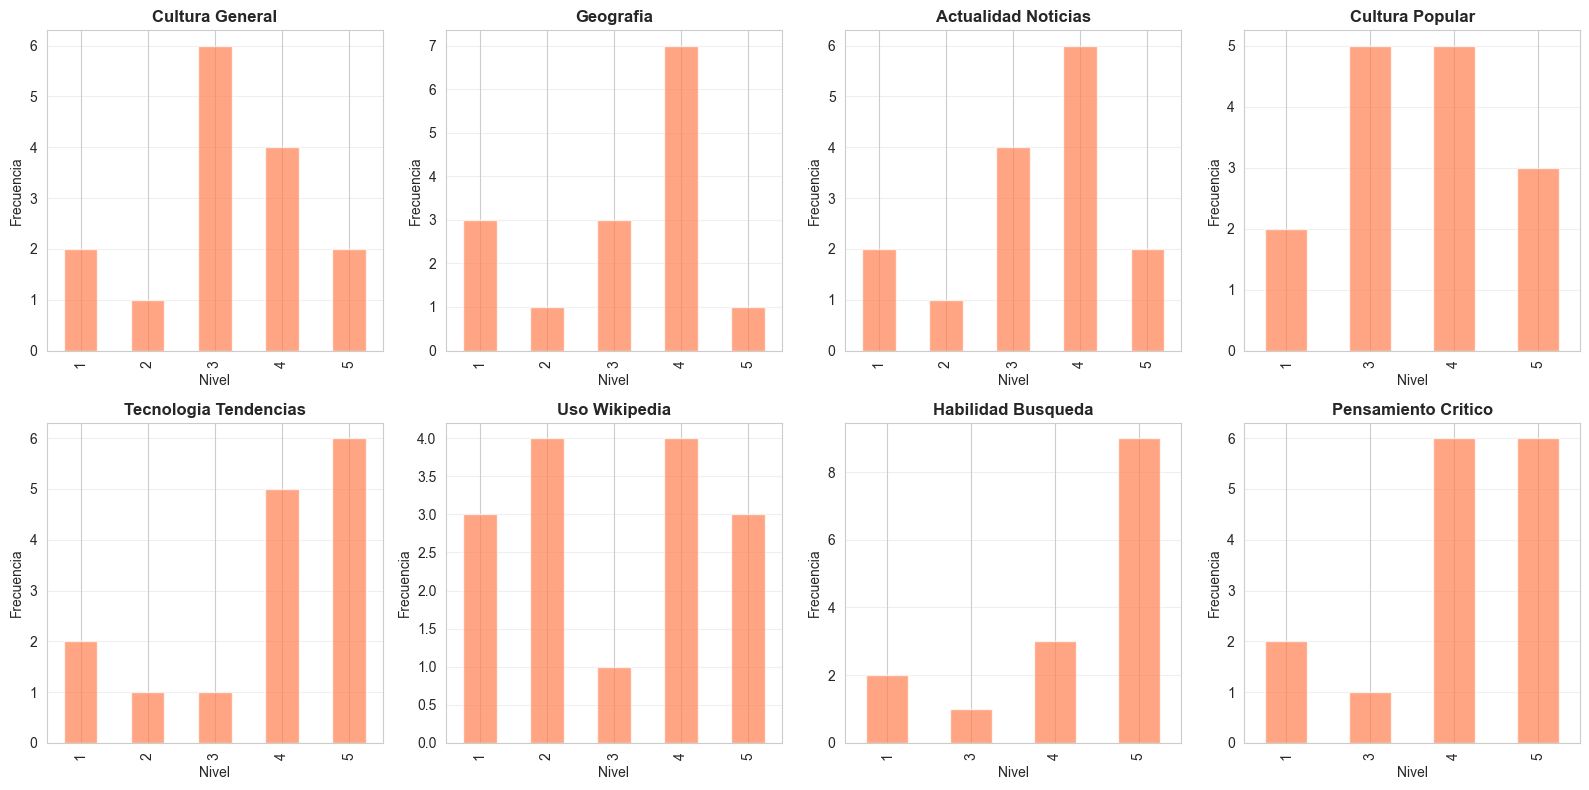

In [12]:
# Visualización de perfiles de conocimiento
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(knowledge_cols):
    if idx < len(axes):
        df_profiles[col].value_counts().sort_index().plot(kind='bar', ax=axes[idx], color='coral', alpha=0.7)
        axes[idx].set_title(col.replace('_', ' ').title(), fontweight='bold')
        axes[idx].set_xlabel('Nivel')
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
### 6.1 Métricas Avanzadas por Jugador

# Crear un dataframe expandido con columnas de knowledge_profile
df_expanded_enriched = df_expanded.merge(
    df_users_knowledge,
    on='username',
    how='left'
)

print(f"Dataset expandido enriquecido con knowledge_profile: {df_expanded_enriched.shape}")
print(f"Columnas añadidas de knowledge_profile: {knowledge_cols}")
print("\nPrimeras filas del dataset expandido enriquecido:")
print(df_expanded_enriched.head())

Dataset expandido enriquecido con knowledge_profile: (2293, 20)
Columnas añadidas de knowledge_profile: ['cultura_general', 'geografia', 'actualidad_noticias', 'cultura_popular', 'tecnologia_tendencias', 'uso_wikipedia', 'habilidad_busqueda', 'pensamiento_critico']

Primeras filas del dataset expandido enriquecido:
                             session_id                person       username  \
0  c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2  Ludwig van Beethoven  alonso02_rupa   
1  c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2  Ludwig van Beethoven  alonso02_rupa   
2  c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2  Ludwig van Beethoven  alonso02_rupa   
3  c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2  Ludwig van Beethoven  alonso02_rupa   
4  c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2  Ludwig van Beethoven  alonso02_rupa   

   acierto  hint_number  total_hints  \
0    False            1            5   
1    False            2            5   
2    False            3            5   
3    False            4            5   
4 

In [14]:
# Función para calcular métricas por jugador
def calculate_player_metrics(df_sessions, df_users_knowledge, N_early_hints=3):
    """
    Calcula métricas de rendimiento, velocidad y comportamiento por jugador.
    
    Parámetros:
    - df_sessions: DataFrame de sesiones
    - df_users_knowledge: DataFrame de usuarios con knowledge_profile
    - N_early_hints: Número de hints para calcular accuracy temprana
    
    Retorna:
    - DataFrame con métricas por jugador
    """
    
    player_metrics = []
    
    # Agrupar por username (incluyendo sesiones sin username como None/NaN)
    for username in df_sessions['username'].unique():
        # Filtrar sesiones del jugador
        if pd.isna(username):
            player_sessions = df_sessions[df_sessions['username'].isna()].copy()
            username_key = 'anonymous'
        else:
            player_sessions = df_sessions[df_sessions['username'] == username].copy()
            username_key = username
        
        if len(player_sessions) == 0:
            continue
        
        # Métricas básicas
        total_sessions = len(player_sessions)
        
        # === RENDIMIENTO ===
        
        # Accuracy global
        total_guesses = 0
        total_aciertos = 0
        
        for _, session in player_sessions.iterrows():
            guesses = [g for g in session['guesses'] if g != '']
            total_guesses += len(guesses)
            if session['acierto']:
                total_aciertos += 1
        
        accuracy = total_aciertos / total_guesses if total_guesses > 0 else 0
        
        # Accuracy temprana (primeros N hints)
        early_guesses = 0
        early_aciertos = 0
        
        for _, session in player_sessions.iterrows():
            guesses = session['guesses'][:N_early_hints]
            guesses_realizados = [g for g in guesses if g != '']
            early_guesses += len(guesses_realizados)
            
            # Verificar si acertó en los primeros N hints
            if session['acierto']:
                # Verificar cuántos hints se necesitaron
                hints_hasta_acierto = len([g for g in session['guesses'] if g != ''])
                if hints_hasta_acierto <= N_early_hints and hints_hasta_acierto > 0:
                    early_aciertos += 1
        
        accuracy_early = early_aciertos / early_guesses if early_guesses > 0 else 0
        
        # Decay de accuracy (comparar accuracy en primera mitad vs segunda mitad de hints)
        first_half_guesses = 0
        first_half_aciertos = 0
        second_half_guesses = 0
        second_half_aciertos = 0
        
        for _, session in player_sessions.iterrows():
            total_hints = len(session['pista'])
            mid_point = total_hints // 2
            
            # Primera mitad
            first_guesses = [g for g in session['guesses'][:mid_point] if g != '']
            first_half_guesses += len(first_guesses)
            
            # Segunda mitad
            second_guesses = [g for g in session['guesses'][mid_point:] if g != '']
            second_half_guesses += len(second_guesses)
            
            # Acierto en qué mitad
            if session['acierto']:
                hints_hasta_acierto = len([g for g in session['guesses'] if g != ''])
                if hints_hasta_acierto <= mid_point:
                    first_half_aciertos += 1
                else:
                    second_half_aciertos += 1
        
        accuracy_first_half = first_half_aciertos / first_half_guesses if first_half_guesses > 0 else 0
        accuracy_second_half = second_half_aciertos / second_half_guesses if second_half_guesses > 0 else 0
        accuracy_decay = accuracy_first_half - accuracy_second_half
        
        # === VELOCIDAD ===
        # Para tiempos necesitamos timestamp y last_updated
        # Asumimos que timestamp es inicio y last_updated es fin
        
        tiempos_por_sesion = []
        tiempos_por_guess = []
        tiempos_por_hint = []
        
        for _, session in player_sessions.iterrows():
            if pd.notna(session['timestamp']) and pd.notna(session['last_updated']):
                try:
                    start_time = pd.to_datetime(session['timestamp'])
                    end_time = pd.to_datetime(session['last_updated'])
                    tiempo_total = (end_time - start_time).total_seconds()
                    
                    if tiempo_total > 0:
                        tiempos_por_sesion.append(tiempo_total)
                        
                        # Tiempo por guess
                        num_guesses = len([g for g in session['guesses'] if g != ''])
                        if num_guesses > 0:
                            tiempo_por_guess = tiempo_total / num_guesses
                            tiempos_por_guess.append(tiempo_por_guess)
                        
                        # Tiempo por hint (normalizado)
                        num_hints = len(session['pista'])
                        if num_hints > 0:
                            tiempo_por_hint = tiempo_total / num_hints
                            tiempos_por_hint.append(tiempo_por_hint)
                except:
                    pass
        
        tiempo_medio_por_guess = np.mean(tiempos_por_guess) if len(tiempos_por_guess) > 0 else np.nan
        tiempo_medio_por_hint = np.mean(tiempos_por_hint) if len(tiempos_por_hint) > 0 else np.nan
        varianza_tiempos = np.var(tiempos_por_guess) if len(tiempos_por_guess) > 1 else np.nan
        
        # === COMPORTAMIENTO ===
        
        # Número medio de guesses
        guesses_por_sesion = []
        for _, session in player_sessions.iterrows():
            num_guesses = len([g for g in session['guesses'] if g != ''])
            guesses_por_sesion.append(num_guesses)
        
        num_medio_guesses = np.mean(guesses_por_sesion) if len(guesses_por_sesion) > 0 else 0
        
        # Porcentaje de partidas abandonadas (sin acierto)
        partidas_abandonadas = 0
        for _, session in player_sessions.iterrows():
            num_guesses = len([g for g in session['guesses'] if g != ''])
            if not session['acierto']:
                partidas_abandonadas += 1
        
        porcentaje_abandonadas = (partidas_abandonadas / total_sessions * 100) if total_sessions > 0 else 0
        
        # Hint depth medio (hasta qué pista llega)
        hint_depths = []
        for _, session in player_sessions.iterrows():
            # El hint depth es el número total de hints que se dieron
            hint_depth = len(session['pista'])
            hint_depths.append(hint_depth)
        
        hint_depth_medio = np.mean(hint_depths) if len(hint_depths) > 0 else 0
        
        # Construir el diccionario de métricas
        metrics = {
            'username': username_key,
            'total_sessions': total_sessions,
            
            # Rendimiento
            'total_guesses': total_guesses,
            'total_aciertos': total_aciertos,
            'accuracy': accuracy,
            'accuracy_early': accuracy_early,
            'accuracy_first_half': accuracy_first_half,
            'accuracy_second_half': accuracy_second_half,
            'accuracy_decay': accuracy_decay,
            
            # Velocidad
            'tiempo_medio_por_guess': tiempo_medio_por_guess,
            'tiempo_medio_por_hint': tiempo_medio_por_hint,
            'varianza_tiempos': varianza_tiempos,
            
            # Comportamiento
            'num_medio_guesses': num_medio_guesses,
            'porcentaje_abandonadas': porcentaje_abandonadas,
            'hint_depth_medio': hint_depth_medio
        }
        
        player_metrics.append(metrics)
    
    df_player_metrics = pd.DataFrame(player_metrics)
    
    # Merge con knowledge_profile
    df_player_metrics = df_player_metrics.merge(
        df_users_knowledge,
        on='username',
        how='left'
    )
    
    return df_player_metrics

# Calcular métricas
print("Calculando métricas por jugador...")
df_player_metrics = calculate_player_metrics(df_sessions, df_users_knowledge, N_early_hints=3)

print(f"\n=== Métricas por Jugador ===")
print(f"Total de jugadores analizados: {len(df_player_metrics)}")
print(f"\nColumnas del dataframe:")
print(df_player_metrics.columns.tolist())
print(f"\nPrimeras filas:")
print(df_player_metrics.head(10))
print(f"\nEstadísticas descriptivas de métricas:")
print(df_player_metrics.describe())

Calculando métricas por jugador...

=== Métricas por Jugador ===
Total de jugadores analizados: 22

Columnas del dataframe:
['username', 'total_sessions', 'total_guesses', 'total_aciertos', 'accuracy', 'accuracy_early', 'accuracy_first_half', 'accuracy_second_half', 'accuracy_decay', 'tiempo_medio_por_guess', 'tiempo_medio_por_hint', 'varianza_tiempos', 'num_medio_guesses', 'porcentaje_abandonadas', 'hint_depth_medio', 'cultura_general', 'geografia', 'actualidad_noticias', 'cultura_popular', 'tecnologia_tendencias', 'uso_wikipedia', 'habilidad_busqueda', 'pensamiento_critico', 'profile_completed_at']

Primeras filas:
             username  total_sessions  total_guesses  total_aciertos  \
0       alonso02_rupa              50             59              33   
1           anonymous             476            541             299   
2           TrialUser               1              1               1   
3         juanmooreno              14             25              11   
4              

In [15]:
# Guardar los dataframes procesados
import os

# Crear carpeta de resultados si no existe
os.makedirs('results', exist_ok=True)

# Guardar df_expanded_enriched (dataset expandido con knowledge_profile)
df_expanded_enriched.to_csv('results/df_expanded_enriched.csv', index=False, encoding='utf-8')
print(f"✓ Guardado: results/df_expanded_enriched.csv ({len(df_expanded_enriched)} filas)")

# Guardar df_player_metrics (métricas por jugador)
df_player_metrics.to_csv('results/df_player_metrics.csv', index=False, encoding='utf-8')
print(f"✓ Guardado: results/df_player_metrics.csv ({len(df_player_metrics)} filas)")

print("\n=== Resumen de archivos guardados ===")
print(f"1. df_expanded_enriched.csv: Dataset expandido (hint-guess pairs) con columnas de knowledge_profile")
print(f"   - Filas: {len(df_expanded_enriched)}")
print(f"   - Columnas: {len(df_expanded_enriched.columns)}")
print(f"\n2. df_player_metrics.csv: Métricas agregadas por jugador")
print(f"   - Filas: {len(df_player_metrics)}")
print(f"   - Columnas: {len(df_player_metrics.columns)}")
print(f"\nEstos dataframes están listos para clustering y análisis posteriores.")

✓ Guardado: results/df_expanded_enriched.csv (2293 filas)
✓ Guardado: results/df_player_metrics.csv (22 filas)

=== Resumen de archivos guardados ===
1. df_expanded_enriched.csv: Dataset expandido (hint-guess pairs) con columnas de knowledge_profile
   - Filas: 2293
   - Columnas: 20

2. df_player_metrics.csv: Métricas agregadas por jugador
   - Filas: 22
   - Columnas: 24

Estos dataframes están listos para clustering y análisis posteriores.


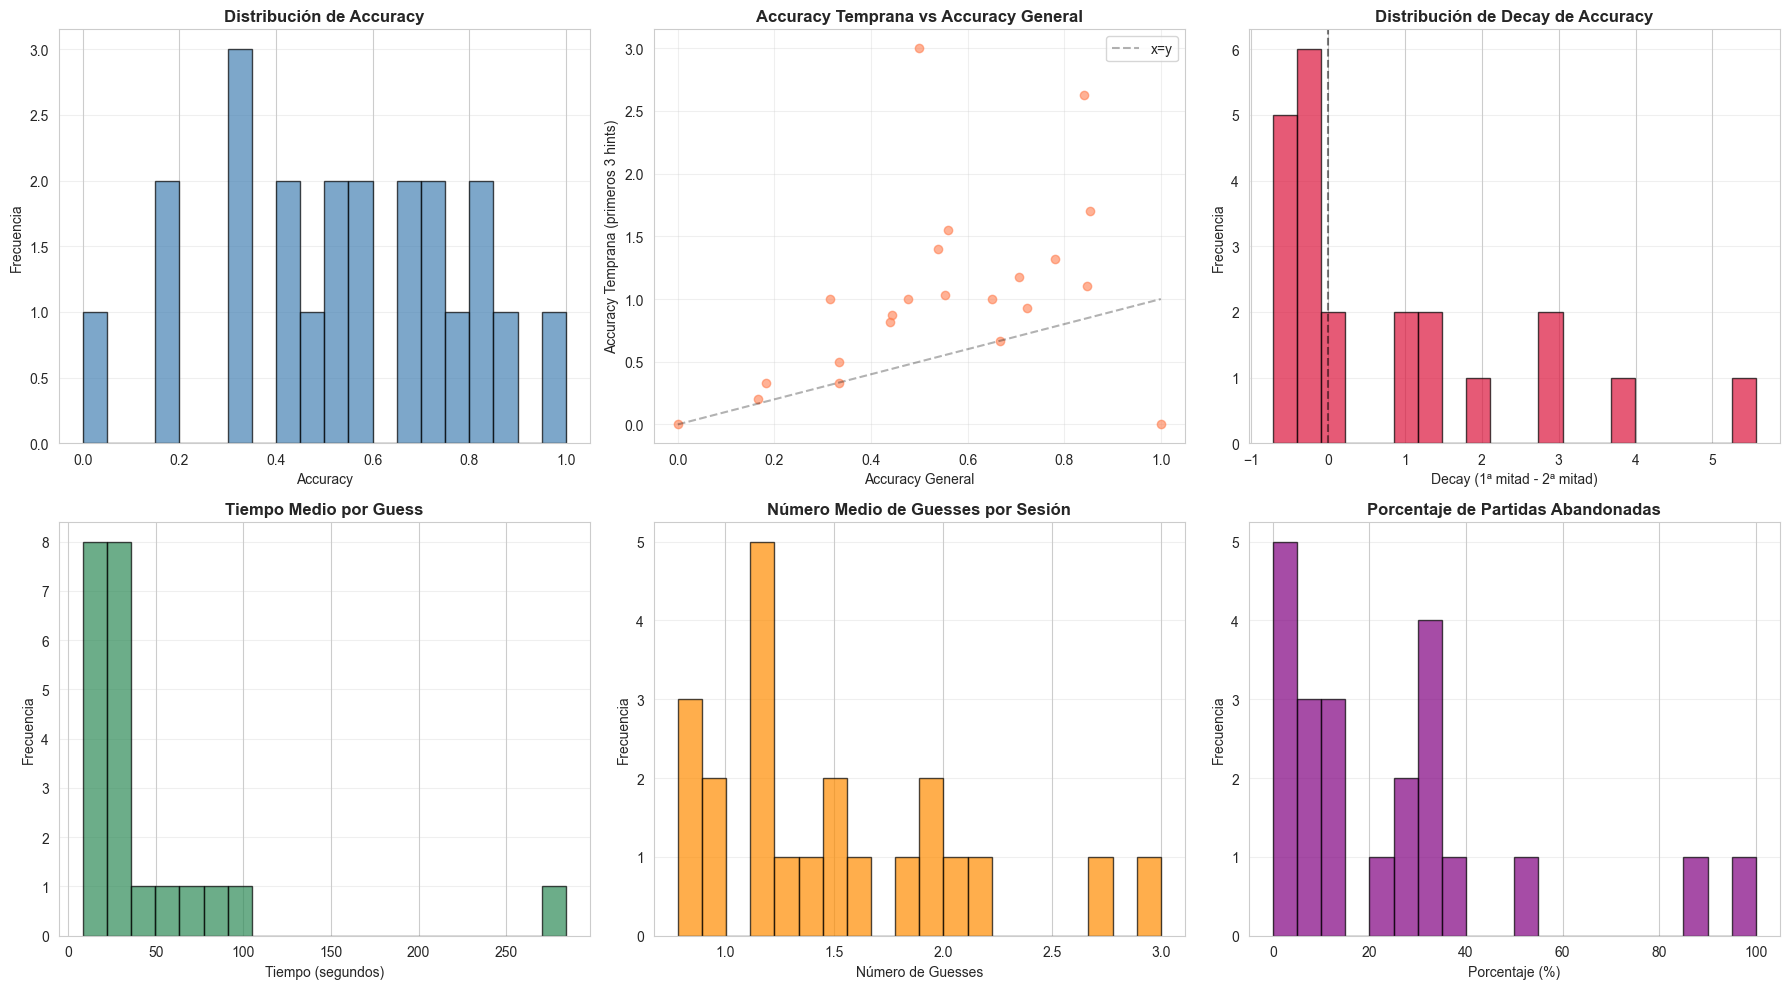


=== Resumen Estadístico de Métricas Clave ===

Rendimiento:
  - Accuracy media: 0.541
  - Accuracy temprana media: 1.025
  - Decay medio: 0.789

Velocidad:
  - Tiempo medio por guess: 45.20s
  - Varianza de tiempos media: 6661.16

Comportamiento:
  - Número medio de guesses: 1.52
  - Porcentaje medio de abandonos: 24.79%
  - Hint depth medio: 3.58


In [16]:
### 6.2 Visualización de Métricas de Jugadores

# Filtrar jugadores con al menos una sesión completa
df_active_players = df_player_metrics[df_player_metrics['total_sessions'] > 0].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribución de Accuracy
axes[0, 0].hist(df_active_players['accuracy'].dropna(), bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribución de Accuracy', fontweight='bold')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Accuracy Early vs Accuracy General
axes[0, 1].scatter(df_active_players['accuracy'], df_active_players['accuracy_early'], 
                   alpha=0.6, color='coral')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='x=y')
axes[0, 1].set_title('Accuracy Temprana vs Accuracy General', fontweight='bold')
axes[0, 1].set_xlabel('Accuracy General')
axes[0, 1].set_ylabel('Accuracy Temprana (primeros 3 hints)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Decay de Accuracy
axes[0, 2].hist(df_active_players['accuracy_decay'].dropna(), bins=20, color='crimson', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Distribución de Decay de Accuracy', fontweight='bold')
axes[0, 2].set_xlabel('Decay (1ª mitad - 2ª mitad)')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Tiempo medio por guess
axes[1, 0].hist(df_active_players['tiempo_medio_por_guess'].dropna(), bins=20, 
                color='seagreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Tiempo Medio por Guess', fontweight='bold')
axes[1, 0].set_xlabel('Tiempo (segundos)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Número medio de guesses
axes[1, 1].hist(df_active_players['num_medio_guesses'].dropna(), bins=20, 
                color='darkorange', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Número Medio de Guesses por Sesión', fontweight='bold')
axes[1, 1].set_xlabel('Número de Guesses')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Porcentaje de partidas abandonadas
axes[1, 2].hist(df_active_players['porcentaje_abandonadas'].dropna(), bins=20, 
                color='purple', alpha=0.7, edgecolor='black')
axes[1, 2].set_title('Porcentaje de Partidas Abandonadas', fontweight='bold')
axes[1, 2].set_xlabel('Porcentaje (%)')
axes[1, 2].set_ylabel('Frecuencia')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Resumen Estadístico de Métricas Clave ===")
print("\nRendimiento:")
print(f"  - Accuracy media: {df_active_players['accuracy'].mean():.3f}")
print(f"  - Accuracy temprana media: {df_active_players['accuracy_early'].mean():.3f}")
print(f"  - Decay medio: {df_active_players['accuracy_decay'].mean():.3f}")
print("\nVelocidad:")
print(f"  - Tiempo medio por guess: {df_active_players['tiempo_medio_por_guess'].mean():.2f}s")
print(f"  - Varianza de tiempos media: {df_active_players['varianza_tiempos'].mean():.2f}")
print("\nComportamiento:")
print(f"  - Número medio de guesses: {df_active_players['num_medio_guesses'].mean():.2f}")
print(f"  - Porcentaje medio de abandonos: {df_active_players['porcentaje_abandonadas'].mean():.2f}%")
print(f"  - Hint depth medio: {df_active_players['hint_depth_medio'].mean():.2f}")

## 8. Representación Latente de Usuarios (Embeddings)

En esta sección, redefinimos el concepto de "usuario" no como un perfil fijo basado únicamente en sus declaraciones de conocimiento, sino como un **estado latente** o **embedding** $z_u \in \mathbb{R}^k$ que captura tanto:
- Competencias declaradas (knowledge_profile)
- Métricas reales de comportamiento en el juego

Esta representación compacta nos permite modelar el comportamiento y habilidades del jugador de forma más robusta.

In [17]:
### 8.1 Preparación de Datos para Embeddings

# Filtrar jugadores activos (con al menos una sesión)
df_embedding = df_player_metrics[df_player_metrics['total_sessions'] > 0].copy()

print(f"=== Preparación de Datos ===")
print(f"Jugadores activos: {len(df_embedding)}")

# Identificar tipos de variables
# Métricas continuas de comportamiento
continuous_metrics = [
    'accuracy', 'accuracy_early', 'accuracy_first_half', 'accuracy_second_half', 'accuracy_decay',
    'tiempo_medio_por_guess', 'tiempo_medio_por_hint', 'varianza_tiempos',
    'num_medio_guesses', 'porcentaje_abandonadas', 'hint_depth_medio',
    'total_sessions', 'total_guesses', 'total_aciertos'
]

# Variables ordinales de knowledge_profile (1-5)
ordinal_metrics = [col for col in knowledge_cols if col in df_embedding.columns]

print(f"\nMétricas continuas ({len(continuous_metrics)}):")
print(continuous_metrics)
print(f"\nMétricas ordinales ({len(ordinal_metrics)}):")
print(ordinal_metrics)

# Verificar valores faltantes
print(f"\n=== Análisis de Valores Faltantes ===")
missing_continuous = df_embedding[continuous_metrics].isnull().sum()
missing_ordinal = df_embedding[ordinal_metrics].isnull().sum() if len(ordinal_metrics) > 0 else pd.Series()

print(f"\nMétricas continuas con valores faltantes:")
print(missing_continuous[missing_continuous > 0])
print(f"\nMétricas ordinales con valores faltantes:")
if len(ordinal_metrics) > 0:
    print(missing_ordinal[missing_ordinal > 0])
else:
    print("No hay métricas ordinales disponibles")

=== Preparación de Datos ===
Jugadores activos: 22

Métricas continuas (14):
['accuracy', 'accuracy_early', 'accuracy_first_half', 'accuracy_second_half', 'accuracy_decay', 'tiempo_medio_por_guess', 'tiempo_medio_por_hint', 'varianza_tiempos', 'num_medio_guesses', 'porcentaje_abandonadas', 'hint_depth_medio', 'total_sessions', 'total_guesses', 'total_aciertos']

Métricas ordinales (8):
['cultura_general', 'geografia', 'actualidad_noticias', 'cultura_popular', 'tecnologia_tendencias', 'uso_wikipedia', 'habilidad_busqueda', 'pensamiento_critico']

=== Análisis de Valores Faltantes ===

Métricas continuas con valores faltantes:
varianza_tiempos    3
dtype: int64

Métricas ordinales con valores faltantes:
cultura_general          7
geografia                7
actualidad_noticias      7
cultura_popular          7
tecnologia_tendencias    7
uso_wikipedia            7
habilidad_busqueda       7
pensamiento_critico      7
dtype: int64


In [18]:
### 8.2 Normalización de Datos

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# === TRATAMIENTO DE MÉTRICAS CONTINUAS ===
# Imputar valores faltantes con la mediana
imputer_continuous = SimpleImputer(strategy='median')
df_continuous_imputed = pd.DataFrame(
    imputer_continuous.fit_transform(df_embedding[continuous_metrics]),
    columns=continuous_metrics,
    index=df_embedding.index
)

# Normalización: z-score (media 0, desviación estándar 1)
scaler = StandardScaler()
df_continuous_normalized = pd.DataFrame(
    scaler.fit_transform(df_continuous_imputed),
    columns=continuous_metrics,
    index=df_embedding.index
)

print("=== Normalización de Métricas Continuas ===")
print(f"Shape: {df_continuous_normalized.shape}")
print(f"\nEstadísticas después de normalización (z-score):")
print(df_continuous_normalized.describe())

# === TRATAMIENTO DE MÉTRICAS ORDINALES ===
# NO aplicamos z-score, mantenemos su naturaleza ordinal (1-5)
# Solo imputamos valores faltantes con la moda
if len(ordinal_metrics) > 0:
    imputer_ordinal = SimpleImputer(strategy='most_frequent')
    df_ordinal_imputed = pd.DataFrame(
        imputer_ordinal.fit_transform(df_embedding[ordinal_metrics]),
        columns=ordinal_metrics,
        index=df_embedding.index
    )
    
    print(f"\n=== Métricas Ordinales (sin normalización) ===")
    print(f"Shape: {df_ordinal_imputed.shape}")
    print(f"\nDistribución de valores (manteniendo escala 1-5):")
    print(df_ordinal_imputed.describe())
    
    # Combinar métricas continuas normalizadas y ordinales sin normalizar
    df_features = pd.concat([df_continuous_normalized, df_ordinal_imputed], axis=1)
else:
    print(f"\n=== No hay métricas ordinales disponibles ===")
    df_features = df_continuous_normalized

print(f"\n=== Dataset Final para Embeddings ===")
print(f"Shape: {df_features.shape}")
print(f"Columnas: {df_features.columns.tolist()}")

# Guardar índice de usernames
usernames = df_embedding['username'].values

=== Normalización de Métricas Continuas ===
Shape: (22, 14)

Estadísticas después de normalización (z-score):
           accuracy  accuracy_early  accuracy_first_half  \
count  2.200000e+01    2.200000e+01         2.200000e+01   
mean  -3.936245e-16   -2.321375e-16        -2.018587e-17   
std    1.023533e+00    1.023533e+00         1.023533e+00   
min   -2.176363e+00   -1.407633e+00        -6.747820e-01   
25%   -7.287635e-01   -6.639665e-01        -6.747820e-01   
50%    1.743762e-02   -3.471004e-02        -6.747820e-01   
75%    7.113462e-01    3.496337e-01         3.847721e-01   
max    1.844748e+00    2.711137e+00         2.974793e+00   

       accuracy_second_half  accuracy_decay  tiempo_medio_por_guess  \
count          2.200000e+01    2.200000e+01            2.200000e+01   
mean          -8.578996e-17   -4.037175e-17           -8.074349e-17   
std            1.023533e+00    1.023533e+00            1.023533e+00   
min           -1.748590e+00   -9.176334e-01           -6.517742e-

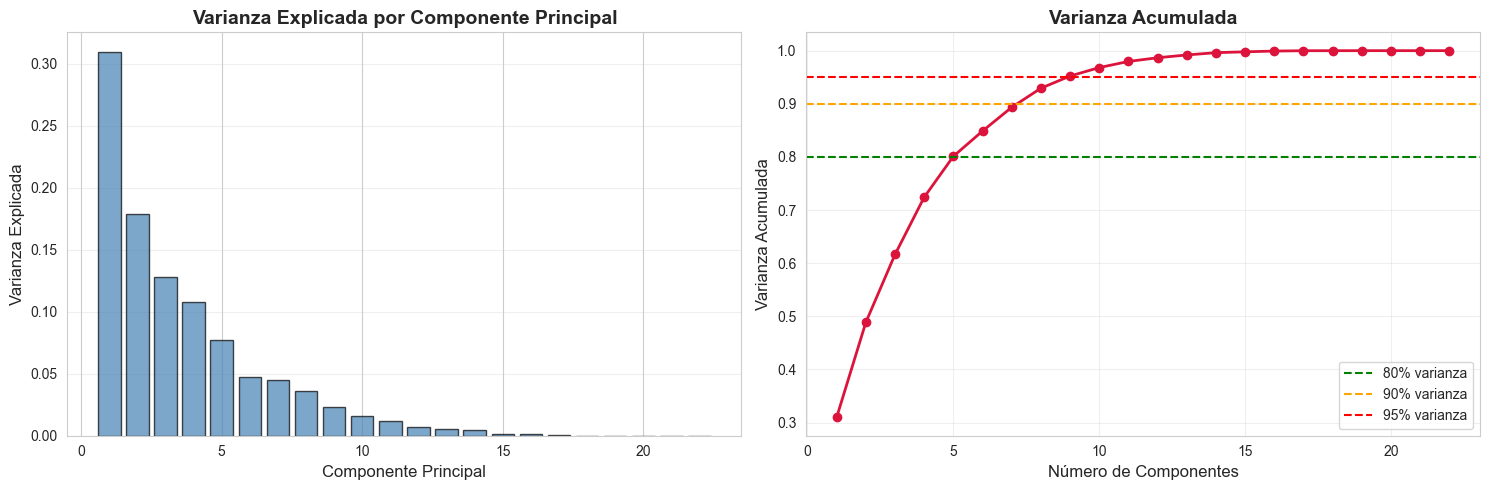


=== Análisis de Componentes Principales ===
Componentes originales: 22

Componentes necesarias para:
  - 80% de varianza: 5
  - 90% de varianza: 8
  - 95% de varianza: 9

=== Embedding Final (Z_u) ===
Dimensionalidad reducida: 22 → 5
Varianza preservada: 80.11%
Shape del embedding: (22, 5)

Primeras filas del embedding:
        PC1       PC2       PC3       PC4       PC5       username
0  0.805871 -0.955289  0.210382 -1.102943  0.905045  alonso02_rupa
1  1.480724 -3.015390  7.092479 -1.539425 -0.484520      anonymous
2 -7.983778 -1.235870 -0.579000 -0.230305  1.016025      TrialUser
3  1.135422  0.209006 -0.700827 -0.749645  0.584637    juanmooreno
4 -2.686751  2.656212 -0.256259 -4.829376 -1.602527          Laura


In [19]:
### 8.3 Reducción Dimensional (PCA)

from sklearn.decomposition import PCA

# Aplicar PCA para:
# 1. Eliminar colinealidad entre variables
# 2. Facilitar la visualización
# 3. Reducir ruido

# Calcular PCA completo para análisis de varianza explicada
pca_full = PCA()
pca_full.fit(df_features)

# Analizar varianza explicada
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Visualización de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Varianza por componente
axes[0].bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 
            alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal', fontsize=12)
axes[0].set_ylabel('Varianza Explicada', fontsize=12)
axes[0].set_title('Varianza Explicada por Componente Principal', fontweight='bold', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Varianza acumulada
axes[1].plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 
             marker='o', linewidth=2, color='crimson')
axes[1].axhline(y=0.80, color='green', linestyle='--', label='80% varianza')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% varianza')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
axes[1].set_xlabel('Número de Componentes', fontsize=12)
axes[1].set_ylabel('Varianza Acumulada', fontsize=12)
axes[1].set_title('Varianza Acumulada', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Encontrar número óptimo de componentes (80%, 90%, 95%)
n_components_80 = np.argmax(cumulative_variance_ratio >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance_ratio >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1

print(f"\n=== Análisis de Componentes Principales ===")
print(f"Componentes originales: {df_features.shape[1]}")
print(f"\nComponentes necesarias para:")
print(f"  - 80% de varianza: {n_components_80}")
print(f"  - 90% de varianza: {n_components_90}")
print(f"  - 95% de varianza: {n_components_95}")

# Aplicar PCA con número óptimo de componentes (80% como criterio conservador)
n_components_optimal = n_components_80
pca = PCA(n_components=n_components_optimal)
Z_u = pca.fit_transform(df_features)

print(f"\n=== Embedding Final (Z_u) ===")
print(f"Dimensionalidad reducida: {df_features.shape[1]} → {Z_u.shape[1]}")
print(f"Varianza preservada: {cumulative_variance_ratio[n_components_optimal-1]:.2%}")
print(f"Shape del embedding: {Z_u.shape}")

# Crear DataFrame con embeddings
df_embeddings = pd.DataFrame(
    Z_u,
    columns=[f'PC{i+1}' for i in range(Z_u.shape[1])],
    index=df_embedding.index
)
df_embeddings['username'] = usernames

print(f"\nPrimeras filas del embedding:")
print(df_embeddings.head())

In [20]:
### 8.4 Reducción Dimensional Alternativa (UMAP)

# UMAP es útil para preservar estructura local y visualización
try:
    from umap import UMAP
    
    # Aplicar UMAP para visualización en 2D
    umap_2d = UMAP(n_components=2, random_state=42, n_neighbors=min(15, len(df_features)-1))
    Z_u_umap_2d = umap_2d.fit_transform(df_features)
    
    # También en 3D para análisis más rico
    umap_3d = UMAP(n_components=3, random_state=42, n_neighbors=min(15, len(df_features)-1))
    Z_u_umap_3d = umap_3d.fit_transform(df_features)
    
    print("=== UMAP Aplicado con Éxito ===")
    print(f"UMAP 2D shape: {Z_u_umap_2d.shape}")
    print(f"UMAP 3D shape: {Z_u_umap_3d.shape}")
    
    # Crear DataFrames
    df_umap_2d = pd.DataFrame(
        Z_u_umap_2d,
        columns=['UMAP1', 'UMAP2'],
        index=df_embedding.index
    )
    df_umap_2d['username'] = usernames
    
    df_umap_3d = pd.DataFrame(
        Z_u_umap_3d,
        columns=['UMAP1', 'UMAP2', 'UMAP3'],
        index=df_embedding.index
    )
    df_umap_3d['username'] = usernames
    
    umap_available = True
    
except ImportError:
    print("=== UMAP no disponible ===")
    print("Para instalar: pip install umap-learn")
    print("Continuando solo con PCA...")
    umap_available = False

c:\Users\Alonso\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Alonso\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


=== UMAP Aplicado con Éxito ===
UMAP 2D shape: (22, 2)
UMAP 3D shape: (22, 3)


c:\Users\Alonso\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 9. Clustering de Usuarios

Ahora aplicamos clustering sobre el espacio de embeddings $Z_u$ para descubrir grupos de usuarios con comportamientos similares.

**Importante**: El PCA/UMAP anterior se usó para:
- Eliminar colinealidad entre variables
- Facilitar la visualización
- Reducir ruido dimensional

**NO** decimos que PCA "descubre perfiles". Los clusters surgirán del algoritmo de clustering aplicado sobre los embeddings normalizados.

=== Evaluando diferentes valores de k ===
k=2: Silhouette=0.486, Davies-Bouldin=0.545
k=3: Silhouette=0.473, Davies-Bouldin=0.466
k=4: Silhouette=0.457, Davies-Bouldin=0.411
k=5: Silhouette=0.257, Davies-Bouldin=0.969
k=6: Silhouette=0.292, Davies-Bouldin=0.711
k=7: Silhouette=0.276, Davies-Bouldin=0.739
k=8: Silhouette=0.238, Davies-Bouldin=0.744
k=9: Silhouette=0.268, Davies-Bouldin=0.573
k=10: Silhouette=0.279, Davies-Bouldin=0.540


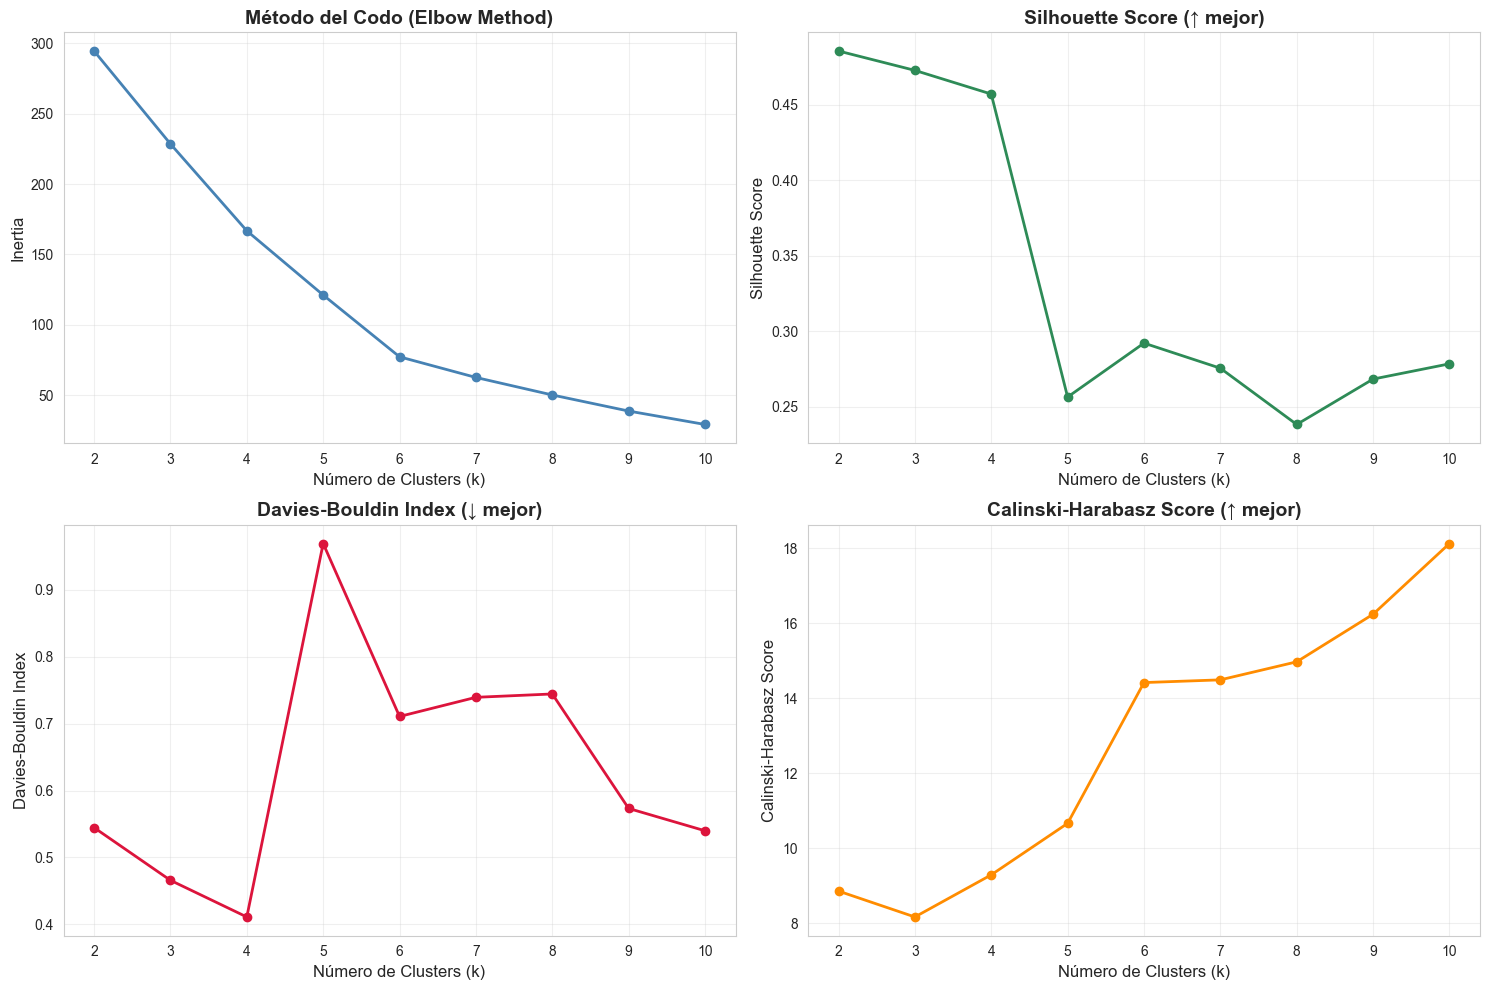


=== Valores Óptimos de k según Métricas ===
Mejor k según Silhouette Score: 2
Mejor k según Davies-Bouldin: 4
Mejor k según Calinski-Harabasz: 10

k óptimo seleccionado (consenso): 2


In [21]:
### 9.1 Determinación del Número Óptimo de Clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Probar diferentes números de clusters
k_range = range(2, min(11, len(Z_u)))  # Hasta 10 clusters o menos si hay pocos datos
metrics_results = {
    'k': [],
    'inertia': [],
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': []
}

print("=== Evaluando diferentes valores de k ===")
for k in k_range:
    # Aplicar K-Means sobre los embeddings PCA
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Z_u)
    
    # Calcular métricas
    inertia = kmeans.inertia_
    silhouette = silhouette_score(Z_u, labels)
    davies_bouldin = davies_bouldin_score(Z_u, labels)
    calinski_harabasz = calinski_harabasz_score(Z_u, labels)
    
    metrics_results['k'].append(k)
    metrics_results['inertia'].append(inertia)
    metrics_results['silhouette'].append(silhouette)
    metrics_results['davies_bouldin'].append(davies_bouldin)
    metrics_results['calinski_harabasz'].append(calinski_harabasz)
    
    print(f"k={k}: Silhouette={silhouette:.3f}, Davies-Bouldin={davies_bouldin:.3f}")

# Visualizar métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow method (Inertia)
axes[0, 0].plot(metrics_results['k'], metrics_results['inertia'], marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia', fontsize=12)
axes[0, 0].set_title('Método del Codo (Elbow Method)', fontweight='bold', fontsize=14)
axes[0, 0].grid(alpha=0.3)

# Silhouette Score (mayor es mejor)
axes[0, 1].plot(metrics_results['k'], metrics_results['silhouette'], marker='o', linewidth=2, color='seagreen')
axes[0, 1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (↑ mejor)', fontweight='bold', fontsize=14)
axes[0, 1].grid(alpha=0.3)

# Davies-Bouldin Index (menor es mejor)
axes[1, 0].plot(metrics_results['k'], metrics_results['davies_bouldin'], marker='o', linewidth=2, color='crimson')
axes[1, 0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (↓ mejor)', fontweight='bold', fontsize=14)
axes[1, 0].grid(alpha=0.3)

# Calinski-Harabasz Score (mayor es mejor)
axes[1, 1].plot(metrics_results['k'], metrics_results['calinski_harabasz'], marker='o', linewidth=2, color='darkorange')
axes[1, 1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 1].set_title('Calinski-Harabasz Score (↑ mejor)', fontweight='bold', fontsize=14)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Sugerir k óptimo basado en métricas
best_k_silhouette = metrics_results['k'][np.argmax(metrics_results['silhouette'])]
best_k_davies = metrics_results['k'][np.argmin(metrics_results['davies_bouldin'])]
best_k_calinski = metrics_results['k'][np.argmax(metrics_results['calinski_harabasz'])]

print(f"\n=== Valores Óptimos de k según Métricas ===")
print(f"Mejor k según Silhouette Score: {best_k_silhouette}")
print(f"Mejor k según Davies-Bouldin: {best_k_davies}")
print(f"Mejor k según Calinski-Harabasz: {best_k_calinski}")

# Seleccionar k por consenso (moda o más frecuente)
from scipy import stats
k_optimal = int(stats.mode([best_k_silhouette, best_k_davies, best_k_calinski], keepdims=True)[0][0])
print(f"\nk óptimo seleccionado (consenso): {k_optimal}")

In [22]:
### 9.2 Aplicar Clustering Final

# Aplicar K-Means con k óptimo
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(Z_u)

# Añadir labels a los dataframes
df_embeddings['cluster'] = cluster_labels
df_embedding['cluster'] = cluster_labels

print(f"=== Clustering Final con k={k_optimal} ===")
print(f"\nDistribución de usuarios por cluster:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(cluster_counts)

print(f"\nPorcentaje por cluster:")
cluster_percentages = (cluster_counts / len(cluster_labels) * 100).round(2)
for cluster_id, pct in cluster_percentages.items():
    print(f"  Cluster {cluster_id}: {pct}%")

# Métricas finales
final_silhouette = silhouette_score(Z_u, cluster_labels)
final_davies_bouldin = davies_bouldin_score(Z_u, cluster_labels)
final_calinski_harabasz = calinski_harabasz_score(Z_u, cluster_labels)

print(f"\n=== Métricas de Calidad del Clustering ===")
print(f"Silhouette Score: {final_silhouette:.3f}")
print(f"Davies-Bouldin Index: {final_davies_bouldin:.3f}")
print(f"Calinski-Harabasz Score: {final_calinski_harabasz:.3f}")

=== Clustering Final con k=2 ===

Distribución de usuarios por cluster:
0     2
1    20
Name: count, dtype: int64

Porcentaje por cluster:
  Cluster 0: 9.09%
  Cluster 1: 90.91%

=== Métricas de Calidad del Clustering ===
Silhouette Score: 0.486
Davies-Bouldin Index: 0.545
Calinski-Harabasz Score: 8.858


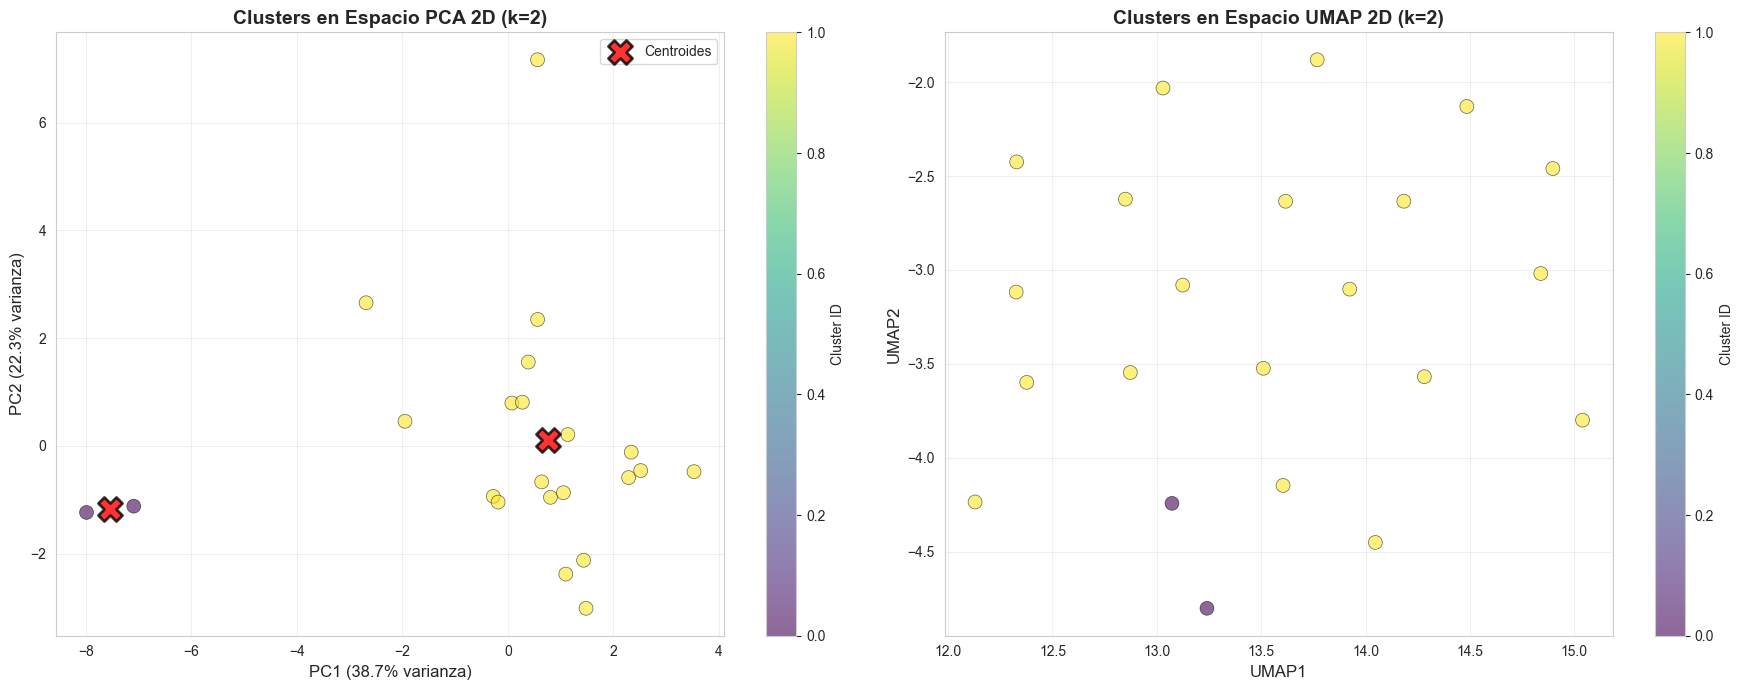

In [23]:
### 9.3 Visualización de Clusters

# Reducir a 2D con PCA para visualización
pca_2d = PCA(n_components=2)
Z_u_2d = pca_2d.fit_transform(Z_u)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: PCA 2D con clusters
scatter = axes[0].scatter(Z_u_2d[:, 0], Z_u_2d[:, 1], c=cluster_labels, 
                          cmap='viridis', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], 
                c='red', s=300, alpha=0.8, marker='X', edgecolors='black', linewidth=2, label='Centroides')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)', fontsize=12)
axes[0].set_title(f'Clusters en Espacio PCA 2D (k={k_optimal})', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster ID')

# Plot 2: UMAP 2D con clusters (si está disponible)
if umap_available:
    scatter2 = axes[1].scatter(Z_u_umap_2d[:, 0], Z_u_umap_2d[:, 1], c=cluster_labels, 
                               cmap='viridis', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[1].set_xlabel('UMAP1', fontsize=12)
    axes[1].set_ylabel('UMAP2', fontsize=12)
    axes[1].set_title(f'Clusters en Espacio UMAP 2D (k={k_optimal})', fontweight='bold', fontsize=14)
    axes[1].grid(alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Cluster ID')
else:
    # Si no hay UMAP, mostrar distribución de clusters
    axes[1].bar(cluster_counts.index, cluster_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Cluster ID', fontsize=12)
    axes[1].set_ylabel('Número de Usuarios', fontsize=12)
    axes[1].set_title('Distribución de Usuarios por Cluster', fontweight='bold', fontsize=14)
    axes[1].grid(axis='y', alpha=0.3)
    
    # Añadir etiquetas de valor
    for i, v in enumerate(cluster_counts.values):
        axes[1].text(cluster_counts.index[i], v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Aunque los números nos dictan que lo mejor sería tener dos clusters, si observamos, existen outliers que tal vez no deberían ser clasificados en un mismo grupo, por lo que nos decantaremos por k=4

In [24]:
### 9.2 Aplicar Clustering Final
k_optimal += 2
# Aplicar K-Means con k óptimo
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(Z_u)

# Añadir labels a los dataframes
df_embeddings['cluster'] = cluster_labels
df_embedding['cluster'] = cluster_labels

print(f"=== Clustering Final con k={k_optimal} ===")
print(f"\nDistribución de usuarios por cluster:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(cluster_counts)

print(f"\nPorcentaje por cluster:")
cluster_percentages = (cluster_counts / len(cluster_labels) * 100).round(2)
for cluster_id, pct in cluster_percentages.items():
    print(f"  Cluster {cluster_id}: {pct}%")

# Métricas finales
final_silhouette = silhouette_score(Z_u, cluster_labels)
final_davies_bouldin = davies_bouldin_score(Z_u, cluster_labels)
final_calinski_harabasz = calinski_harabasz_score(Z_u, cluster_labels)

print(f"\n=== Métricas de Calidad del Clustering ===")
print(f"Silhouette Score: {final_silhouette:.3f}")
print(f"Davies-Bouldin Index: {final_davies_bouldin:.3f}")
print(f"Calinski-Harabasz Score: {final_calinski_harabasz:.3f}")

=== Clustering Final con k=4 ===

Distribución de usuarios por cluster:
0     1
1    18
2     2
3     1
Name: count, dtype: int64

Porcentaje por cluster:
  Cluster 0: 4.55%
  Cluster 1: 81.82%
  Cluster 2: 9.09%
  Cluster 3: 4.55%

=== Métricas de Calidad del Clustering ===
Silhouette Score: 0.457
Davies-Bouldin Index: 0.411
Calinski-Harabasz Score: 9.290


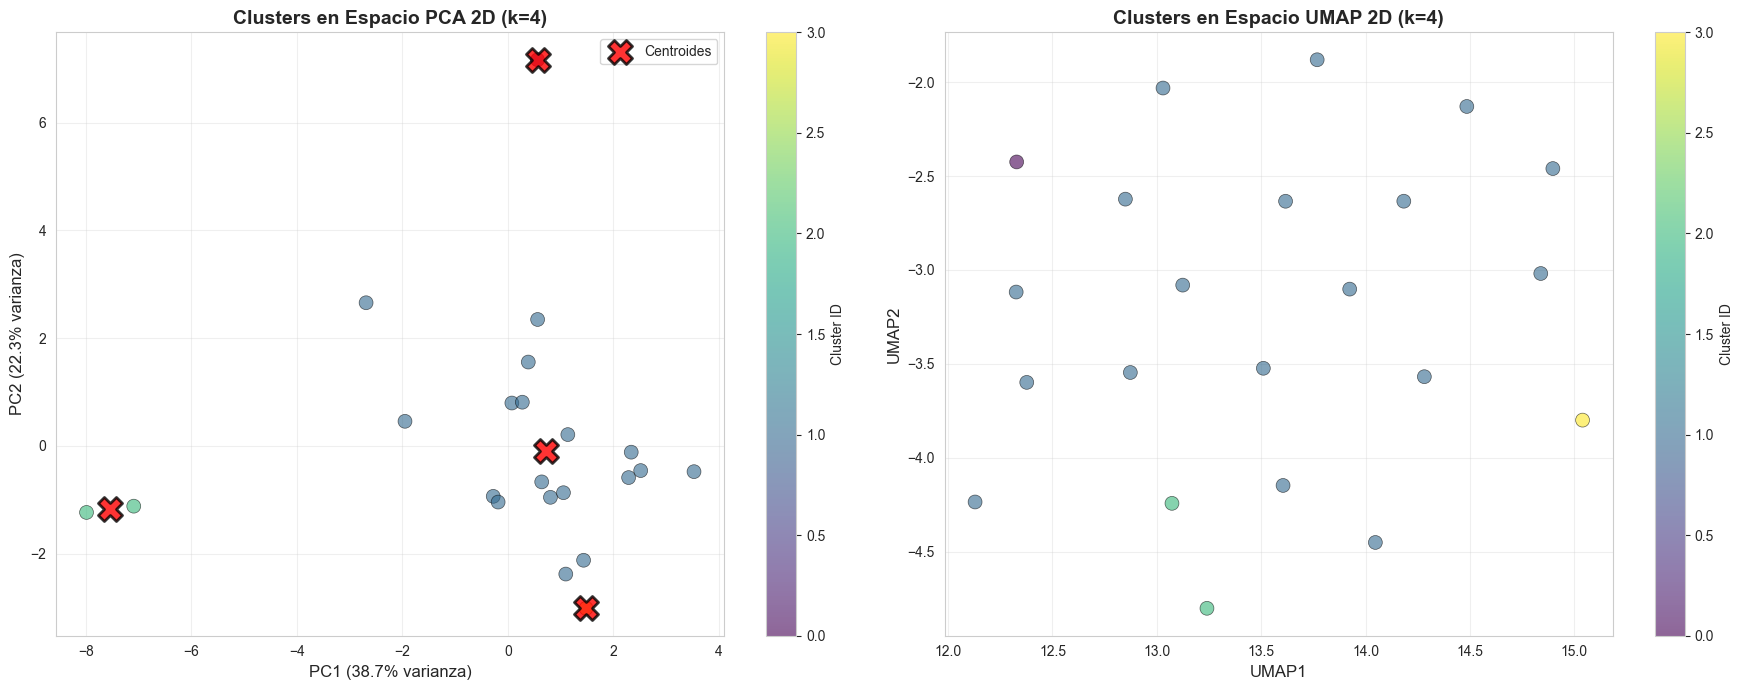

In [25]:
### 9.3 Visualización de Clusters

# Reducir a 2D con PCA para visualización
pca_2d = PCA(n_components=2)
Z_u_2d = pca_2d.fit_transform(Z_u)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: PCA 2D con clusters
scatter = axes[0].scatter(Z_u_2d[:, 0], Z_u_2d[:, 1], c=cluster_labels, 
                          cmap='viridis', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], 
                c='red', s=300, alpha=0.8, marker='X', edgecolors='black', linewidth=2, label='Centroides')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)', fontsize=12)
axes[0].set_title(f'Clusters en Espacio PCA 2D (k={k_optimal})', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster ID')

# Plot 2: UMAP 2D con clusters (si está disponible)
if umap_available:
    scatter2 = axes[1].scatter(Z_u_umap_2d[:, 0], Z_u_umap_2d[:, 1], c=cluster_labels, 
                               cmap='viridis', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[1].set_xlabel('UMAP1', fontsize=12)
    axes[1].set_ylabel('UMAP2', fontsize=12)
    axes[1].set_title(f'Clusters en Espacio UMAP 2D (k={k_optimal})', fontweight='bold', fontsize=14)
    axes[1].grid(alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Cluster ID')
else:
    # Si no hay UMAP, mostrar distribución de clusters
    axes[1].bar(cluster_counts.index, cluster_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Cluster ID', fontsize=12)
    axes[1].set_ylabel('Número de Usuarios', fontsize=12)
    axes[1].set_title('Distribución de Usuarios por Cluster', fontweight='bold', fontsize=14)
    axes[1].grid(axis='y', alpha=0.3)
    
    # Añadir etiquetas de valor
    for i, v in enumerate(cluster_counts.values):
        axes[1].text(cluster_counts.index[i], v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

=== Caracterización de Clusters ===

Perfil promedio de cada cluster:

        accuracy        accuracy_early        accuracy_decay         \
            mean    std           mean    std           mean    std   
cluster                                                               
0          0.182    NaN          0.333    NaN         -0.222    NaN   
1          0.540  0.244          1.129  0.764          0.923  1.810   
2          0.722  0.393          0.438  0.619         -0.235  0.333   
3          0.553    NaN          1.032    NaN          1.434    NaN   

        tiempo_medio_por_guess         num_medio_guesses        ...  \
                          mean     std              mean   std  ...   
cluster                                                         ...   
0                      284.042     NaN             2.750   NaN  ...   
1                       36.280  23.576             1.466  0.55  ...   
2                       13.631   7.418             1.559  0.79  ...   
3    

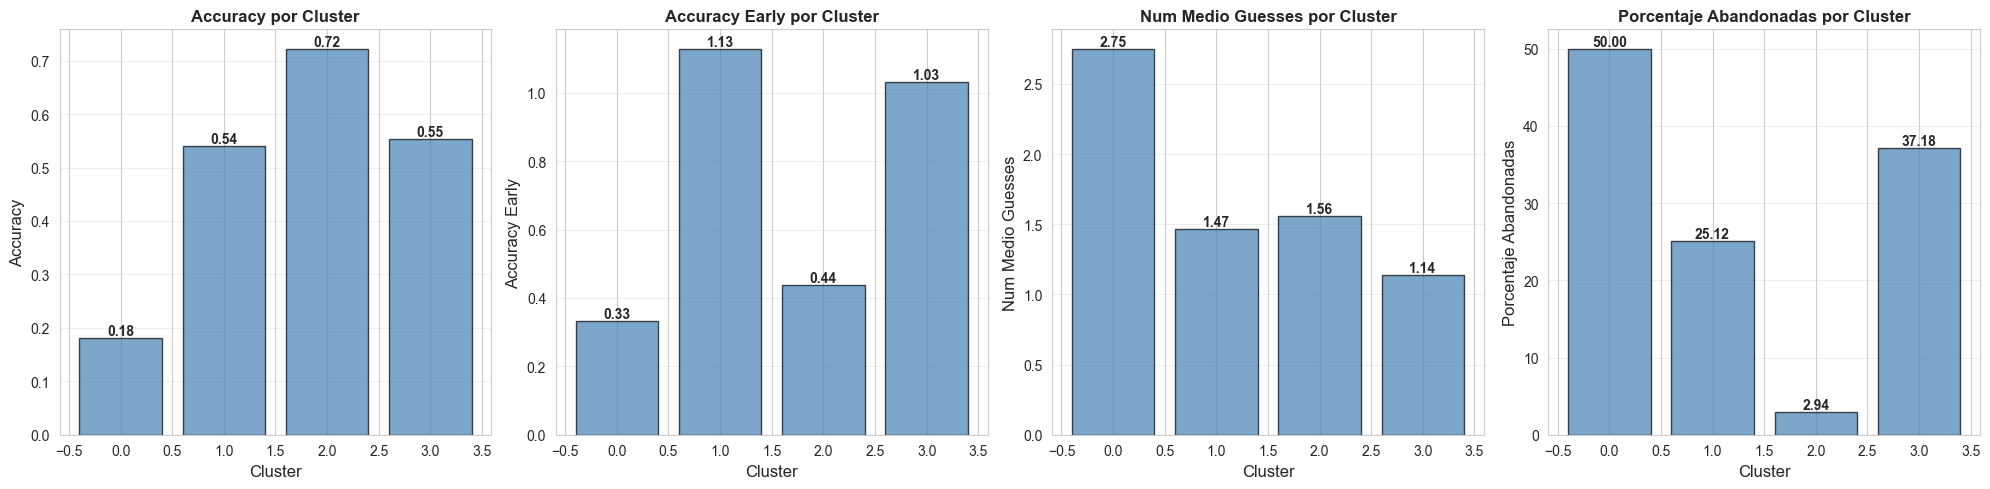

In [26]:
### 9.4 Caracterización de Clusters

# Crear un dataframe con las métricas originales y el cluster asignado
df_cluster_analysis = df_embedding.copy()

print("=== Caracterización de Clusters ===")
print("\nPerfil promedio de cada cluster:\n")

# Métricas clave para caracterizar
key_metrics = [
    'accuracy', 'accuracy_early', 'accuracy_decay',
    'tiempo_medio_por_guess', 'num_medio_guesses', 
    'porcentaje_abandonadas', 'hint_depth_medio',
    'total_sessions'
]

# Añadir métricas ordinales si existen
if len(ordinal_metrics) > 0:
    key_metrics.extend(ordinal_metrics)

# Calcular estadísticas por cluster
cluster_profiles = df_cluster_analysis.groupby('cluster')[key_metrics].agg(['mean', 'std']).round(3)

print(cluster_profiles)

# Visualización de perfiles de clusters
metrics_to_plot = ['accuracy', 'accuracy_early', 'num_medio_guesses', 'porcentaje_abandonadas']
n_metrics = len(metrics_to_plot)
fig, axes = plt.subplots(1, n_metrics, figsize=(5*n_metrics, 5))

if n_metrics == 1:
    axes = [axes]

for idx, metric in enumerate(metrics_to_plot):
    cluster_means = df_cluster_analysis.groupby('cluster')[metric].mean()
    axes[idx].bar(cluster_means.index, cluster_means.values, 
                  color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel('Cluster', fontsize=12)
    axes[idx].set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
    axes[idx].set_title(f'{metric.replace("_", " ").title()} por Cluster', fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Añadir valores
    for i, v in enumerate(cluster_means.values):
        axes[idx].text(cluster_means.index[i], v, f'{v:.2f}', 
                      ha='center', va='bottom' if v >= 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
### 9.5 Interpretación y Etiquetado de Clusters

# Función para generar etiquetas descriptivas automáticamente
def interpret_cluster(cluster_id, df_analysis):
    """
    Genera una interpretación descriptiva de un cluster basada en sus características.
    """
    cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
    
    # Calcular características distintivas
    accuracy_mean = cluster_data['accuracy'].mean()
    early_mean = cluster_data['accuracy_early'].mean()
    sessions_mean = cluster_data['total_sessions'].mean()
    abandon_mean = cluster_data['porcentaje_abandonadas'].mean()
    guesses_mean = cluster_data['num_medio_guesses'].mean()
    
    # Generar etiqueta descriptiva
    labels = []
    
    # Rendimiento
    if accuracy_mean > 0.7:
        labels.append("Alto Rendimiento")
    elif accuracy_mean > 0.4:
        labels.append("Rendimiento Medio")
    else:
        labels.append("Bajo Rendimiento")
    
    # Experiencia
    if sessions_mean > 20:
        labels.append("Muy Experimentado")
    elif sessions_mean > 10:
        labels.append("Experimentado")
    elif sessions_mean > 5:
        labels.append("Moderado")
    else:
        labels.append("Novato")
    
    # Compromiso
    if abandon_mean > 50:
        labels.append("Alta Deserción")
    elif abandon_mean > 25:
        labels.append("Deserción Moderada")
    else:
        labels.append("Comprometido")
    
    return " | ".join(labels)

# Generar interpretaciones
print("\n=== Interpretación de Clusters ===\n")
cluster_interpretations = {}

for cluster_id in sorted(df_cluster_analysis['cluster'].unique()):
    interpretation = interpret_cluster(cluster_id, df_cluster_analysis)
    cluster_interpretations[cluster_id] = interpretation
    
    cluster_data = df_cluster_analysis[df_cluster_analysis['cluster'] == cluster_id]
    n_users = len(cluster_data)
    
    print(f"Cluster {cluster_id}: {interpretation}")
    print(f"  Usuarios: {n_users} ({n_users/len(df_cluster_analysis)*100:.1f}%)")
    print(f"  Accuracy promedio: {cluster_data['accuracy'].mean():.3f}")
    print(f"  Sesiones promedio: {cluster_data['total_sessions'].mean():.1f}")
    print(f"  Abandono promedio: {cluster_data['porcentaje_abandonadas'].mean():.1f}%")
    print()

# Añadir interpretaciones al dataframe
df_cluster_analysis['cluster_label'] = df_cluster_analysis['cluster'].map(cluster_interpretations)


=== Interpretación de Clusters ===

Cluster 0: Bajo Rendimiento | Novato | Deserción Moderada
  Usuarios: 1 (4.5%)
  Accuracy promedio: 0.182
  Sesiones promedio: 4.0
  Abandono promedio: 50.0%

Cluster 1: Rendimiento Medio | Experimentado | Deserción Moderada
  Usuarios: 18 (81.8%)
  Accuracy promedio: 0.540
  Sesiones promedio: 16.2
  Abandono promedio: 25.1%

Cluster 2: Alto Rendimiento | Moderado | Comprometido
  Usuarios: 2 (9.1%)
  Accuracy promedio: 0.722
  Sesiones promedio: 9.0
  Abandono promedio: 2.9%

Cluster 3: Rendimiento Medio | Muy Experimentado | Deserción Moderada
  Usuarios: 1 (4.5%)
  Accuracy promedio: 0.553
  Sesiones promedio: 476.0
  Abandono promedio: 37.2%



In [28]:
### 9.6 Guardar Resultados de Clustering
# Guardar análisis de clusters con todas las métricas
df_cluster_analysis.to_csv('results/user_cluster_analysis.csv', index=False, encoding='utf-8')

## 7. Visualizaciones Adicionales

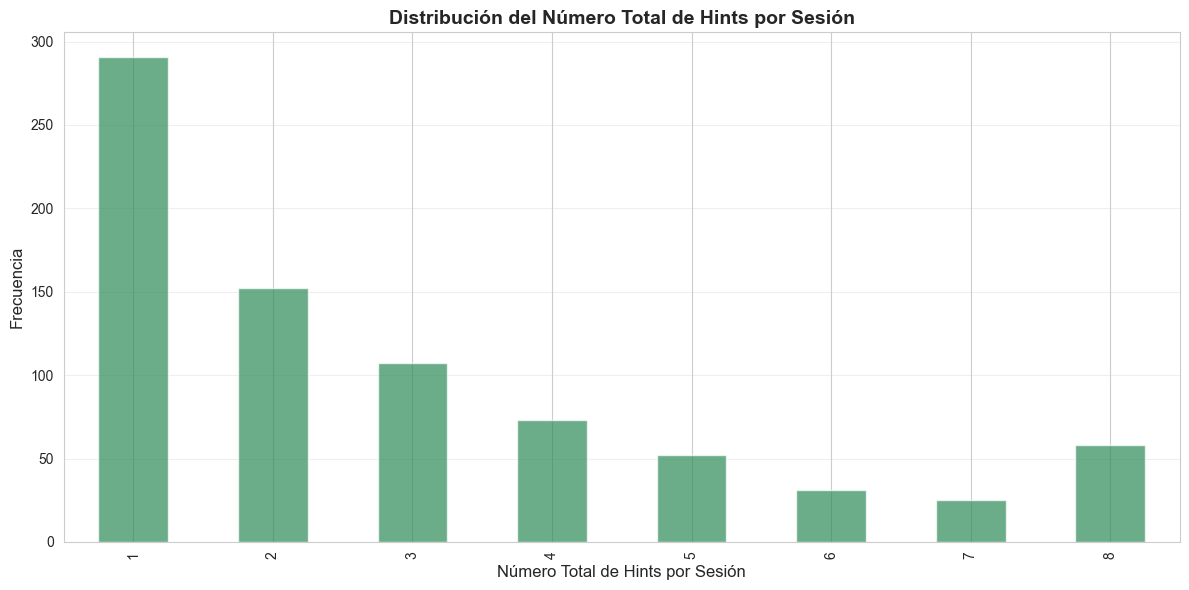


Estadísticas de hints por sesión:
count    789.000000
mean       2.906210
std        2.172468
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        8.000000
Name: total_hints, dtype: float64


In [29]:
# Distribución de total de hints por sesión
plt.figure(figsize=(12, 6))
df_sessions['total_hints'] = df_sessions['pista'].apply(len)
df_sessions['total_hints'].value_counts().sort_index().plot(kind='bar', color='seagreen', alpha=0.7)
plt.xlabel('Número Total de Hints por Sesión', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución del Número Total de Hints por Sesión', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEstadísticas de hints por sesión:")
print(df_sessions['total_hints'].describe())

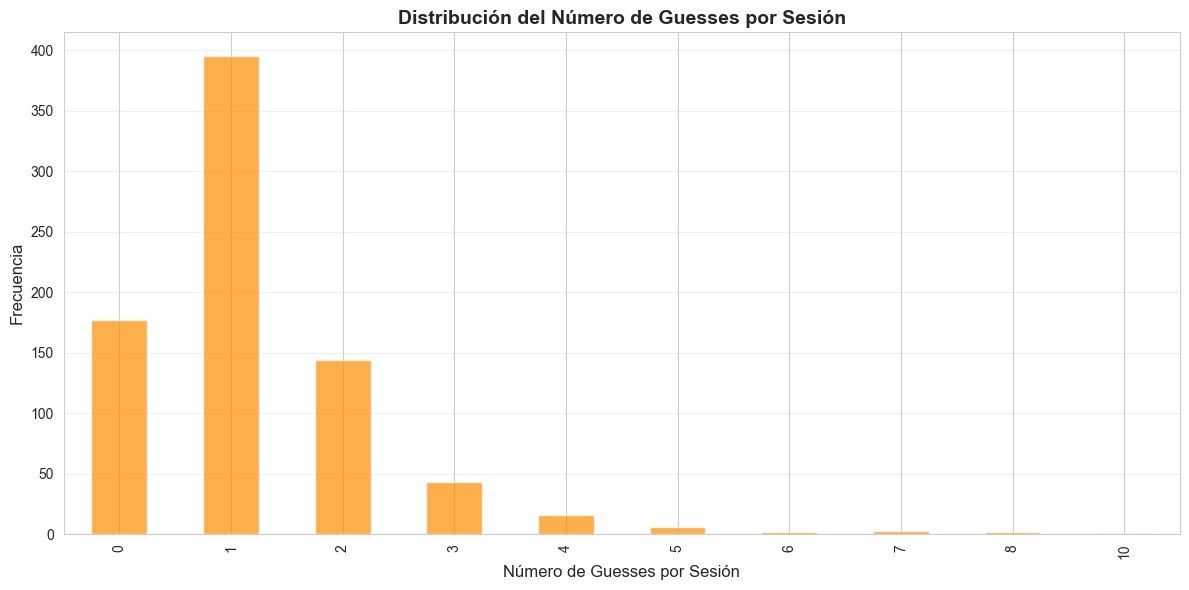


Estadísticas de guesses por sesión:
count    789.000000
mean       1.223067
std        1.143698
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       10.000000
Name: total_guesses, dtype: float64


In [30]:
# Distribución de guesses por sesión
df_sessions['total_guesses'] = df_sessions['guesses'].apply(lambda x: sum([1 for g in x if g != '']))

plt.figure(figsize=(12, 6))
df_sessions['total_guesses'].value_counts().sort_index().plot(kind='bar', color='darkorange', alpha=0.7)
plt.xlabel('Número de Guesses por Sesión', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución del Número de Guesses por Sesión', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEstadísticas de guesses por sesión:")
print(df_sessions['total_guesses'].describe())

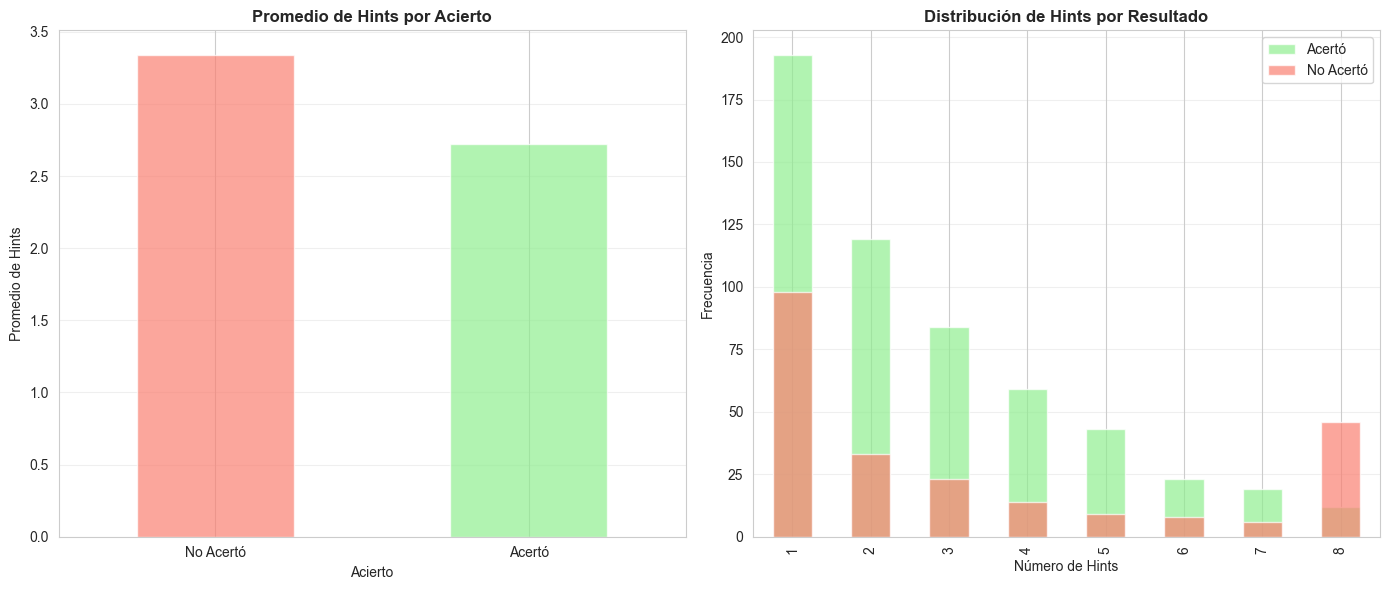

In [31]:
# Relación entre número de hints y acierto
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Por acierto
df_sessions.groupby('acierto')['total_hints'].mean().plot(kind='bar', ax=ax[0], color=['salmon', 'lightgreen'], alpha=0.7)
ax[0].set_title('Promedio de Hints por Acierto', fontweight='bold')
ax[0].set_xlabel('Acierto')
ax[0].set_ylabel('Promedio de Hints')
ax[0].set_xticklabels(['No Acertó', 'Acertó'], rotation=0)
ax[0].grid(axis='y', alpha=0.3)

# Distribución de hints para aciertos vs no aciertos
df_sessions[df_sessions['acierto']]['total_hints'].value_counts().sort_index().plot(
    kind='bar', ax=ax[1], color='lightgreen', alpha=0.7, label='Acertó'
)
df_sessions[~df_sessions['acierto']]['total_hints'].value_counts().sort_index().plot(
    kind='bar', ax=ax[1], color='salmon', alpha=0.7, label='No Acertó'
)
ax[1].set_title('Distribución de Hints por Resultado', fontweight='bold')
ax[1].set_xlabel('Número de Hints')
ax[1].set_ylabel('Frecuencia')
ax[1].legend()
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Exportar Dataset Expandido

In [32]:
df_final = df_expanded.merge(df_cluster_analysis[["username", "cluster"]], on="username", how="left")
df_final.columns

Index(['session_id', 'person', 'username', 'acierto', 'hint_number',
       'total_hints', 'hint', 'guess', 'guess_not_empty', 'timestamp',
       'last_updated', 'cluster'],
      dtype='object')

In [33]:
# Guardar el dataset expandido
df_final.to_csv('results/hints_guesses_expanded.csv', index=False, encoding='utf-8')
print("Dataset expandido guardado en: results/hints_guesses_expanded.csv")
print(f"\nDimensiones: {df_final.shape}")
print(f"Columnas: {df_final.columns.tolist()}")

Dataset expandido guardado en: results/hints_guesses_expanded.csv

Dimensiones: (2293, 12)
Columnas: ['session_id', 'person', 'username', 'acierto', 'hint_number', 'total_hints', 'hint', 'guess', 'guess_not_empty', 'timestamp', 'last_updated', 'cluster']
